# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# ── Visual settings ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
print("Libraries loaded ✓")


Libraries loaded ✓


## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

#df = # TODO: read_csv with correct separator (\s+) and na_values

df=pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')
print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [4]:
# TODO: Print df.describe() to view summary statistics
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** ____398 rows and 9 columns___________

**Q2.** Which column contains missing values and how many?  
**Answer:** ___horsepower column has 6 missing values____________


## Task 3 — Pre-Processing

In [5]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)
print("missing values:")
print(df.isnull().sum())
print(f"\nNaN rows = {df.isnull().any(axis=1).sum()} "
      f"({df.isnull().any(axis=1).mean()*100:.2f}% of data)")

print (df.dropna(inplace=True))
print("\nAfter dropping NaN rows:", df.shape)


missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

NaN rows = 6 (1.51% of data)
None

After dropping NaN rows: (392, 9)


In [6]:
# TODO: Check for and remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [7]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
# 3. Strip & lowercase 'car_name'
df['cylinders']   = df['cylinders'].astype('category')
df['model_year']  = df['model_year'].astype('category')
df['origin']      = df['origin'].map({1:'usa', 2:'europe', 3:'japan'})

# Clean string column
df['car_name'] = df['car_name'].str.strip().str.lower()
print("Updated dtypes:\n", df.dtypes)



Updated dtypes:
 mpg              float64
cylinders       category
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model_year      category
origin               str
car_name             str
dtype: object


In [8]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']  
num_cols = ['mpg','displacement','horsepower','weight','acceleration']

print ("Categorical_Column:", cat_cols)
print ("Numerical_Column:", num_cols)


Categorical_Column: ['cylinders', 'origin', 'model_year']
Numerical_Column: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Task 4 — Feature Engineering

In [9]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'
df['mpg_level'] = pd.cut(
    df['mpg'],
    bins=[0, 17, 29, df['mpg'].max()+1],
    labels=['low','medium','high'],
    right=False
)

# Extract company name
df['car_company'] = df['car_name'].str.split().str[0]

print("New features added:")
print(df[['mpg','mpg_level','car_name','car_company']].head(8))

New features added:
    mpg mpg_level                   car_name car_company
0  18.0    medium  chevrolet chevelle malibu   chevrolet
1  15.0       low          buick skylark 320       buick
2  18.0    medium         plymouth satellite    plymouth
3  16.0       low              amc rebel sst         amc
4  17.0    medium                ford torino        ford
5  15.0       low           ford galaxie 500        ford
6  14.0       low           chevrolet impala   chevrolet
7  14.0       low          plymouth fury iii    plymouth


In [10]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]

## Task 5 — Categorical EDA

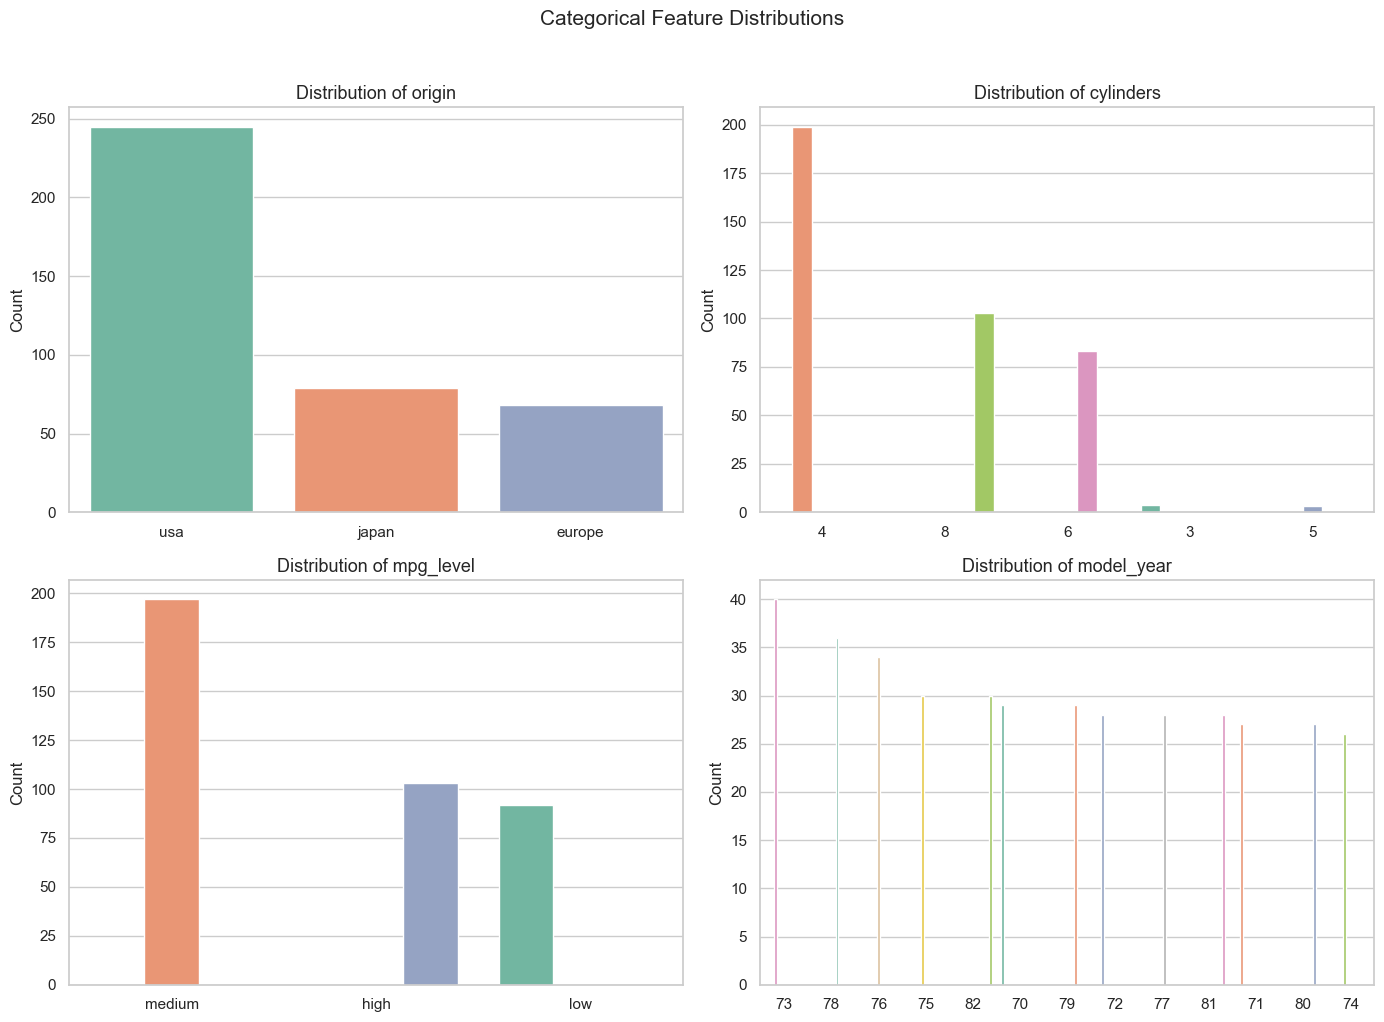

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_plot_cols = ['origin', 'cylinders', 'mpg_level', 'model_year']

for ax, col in zip(axes.flat, cat_plot_cols):
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        x=col,
        hue=col,          # Fix for seaborn warning
        order=order,
        ax=ax,
        palette='Set2',
        legend=False      # Prevent duplicate legend
    )
    
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level

for col in ['origin','cylinders','mpg_level']:
    top = df[col].value_counts(normalize=True).iloc[0]
    print(f"{col}: dominant class = '{df[col].value_counts().index[0]}' → {top*100:.1f}%")



origin: dominant class = 'usa' → 62.5%
cylinders: dominant class = '4' → 50.8%
mpg_level: dominant class = 'medium' → 50.3%


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


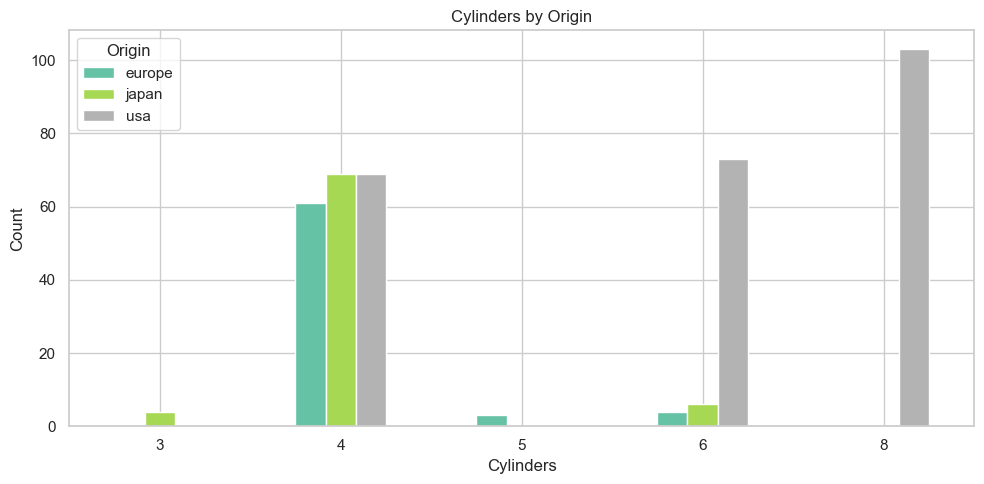

In [16]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart

ct = pd.crosstab(df['cylinders'], df['origin'])
print(ct)

ct.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Cylinders by Origin')
plt.xlabel('Cylinders'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.legend(title='Origin')
plt.tight_layout(); plt.show()


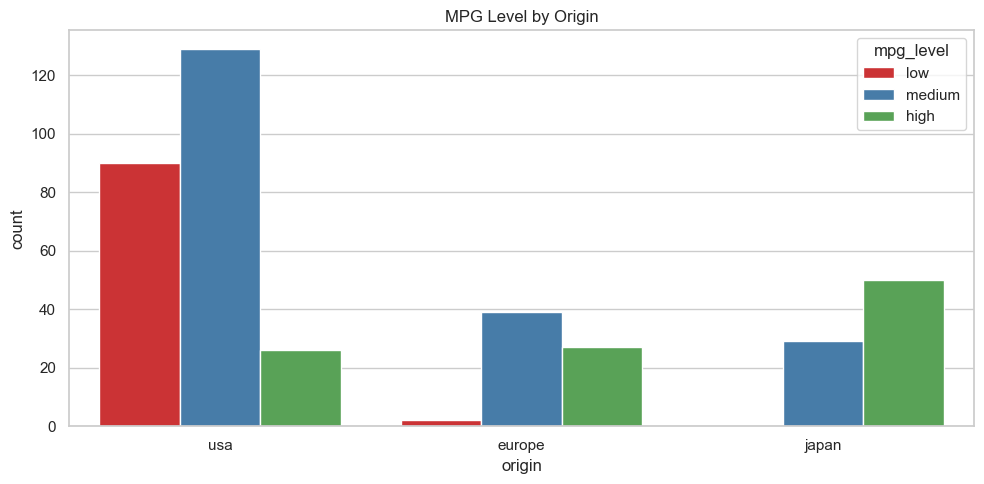

In [13]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='origin', hue='mpg_level',
              order=['usa','europe','japan'],
              hue_order=['low','medium','high'], palette='Set1')
plt.title('MPG Level by Origin')
plt.tight_layout(); plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** ____Japan__________

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** _____4 cylinders, 50 %__________


## Task 6 — Numerical EDA

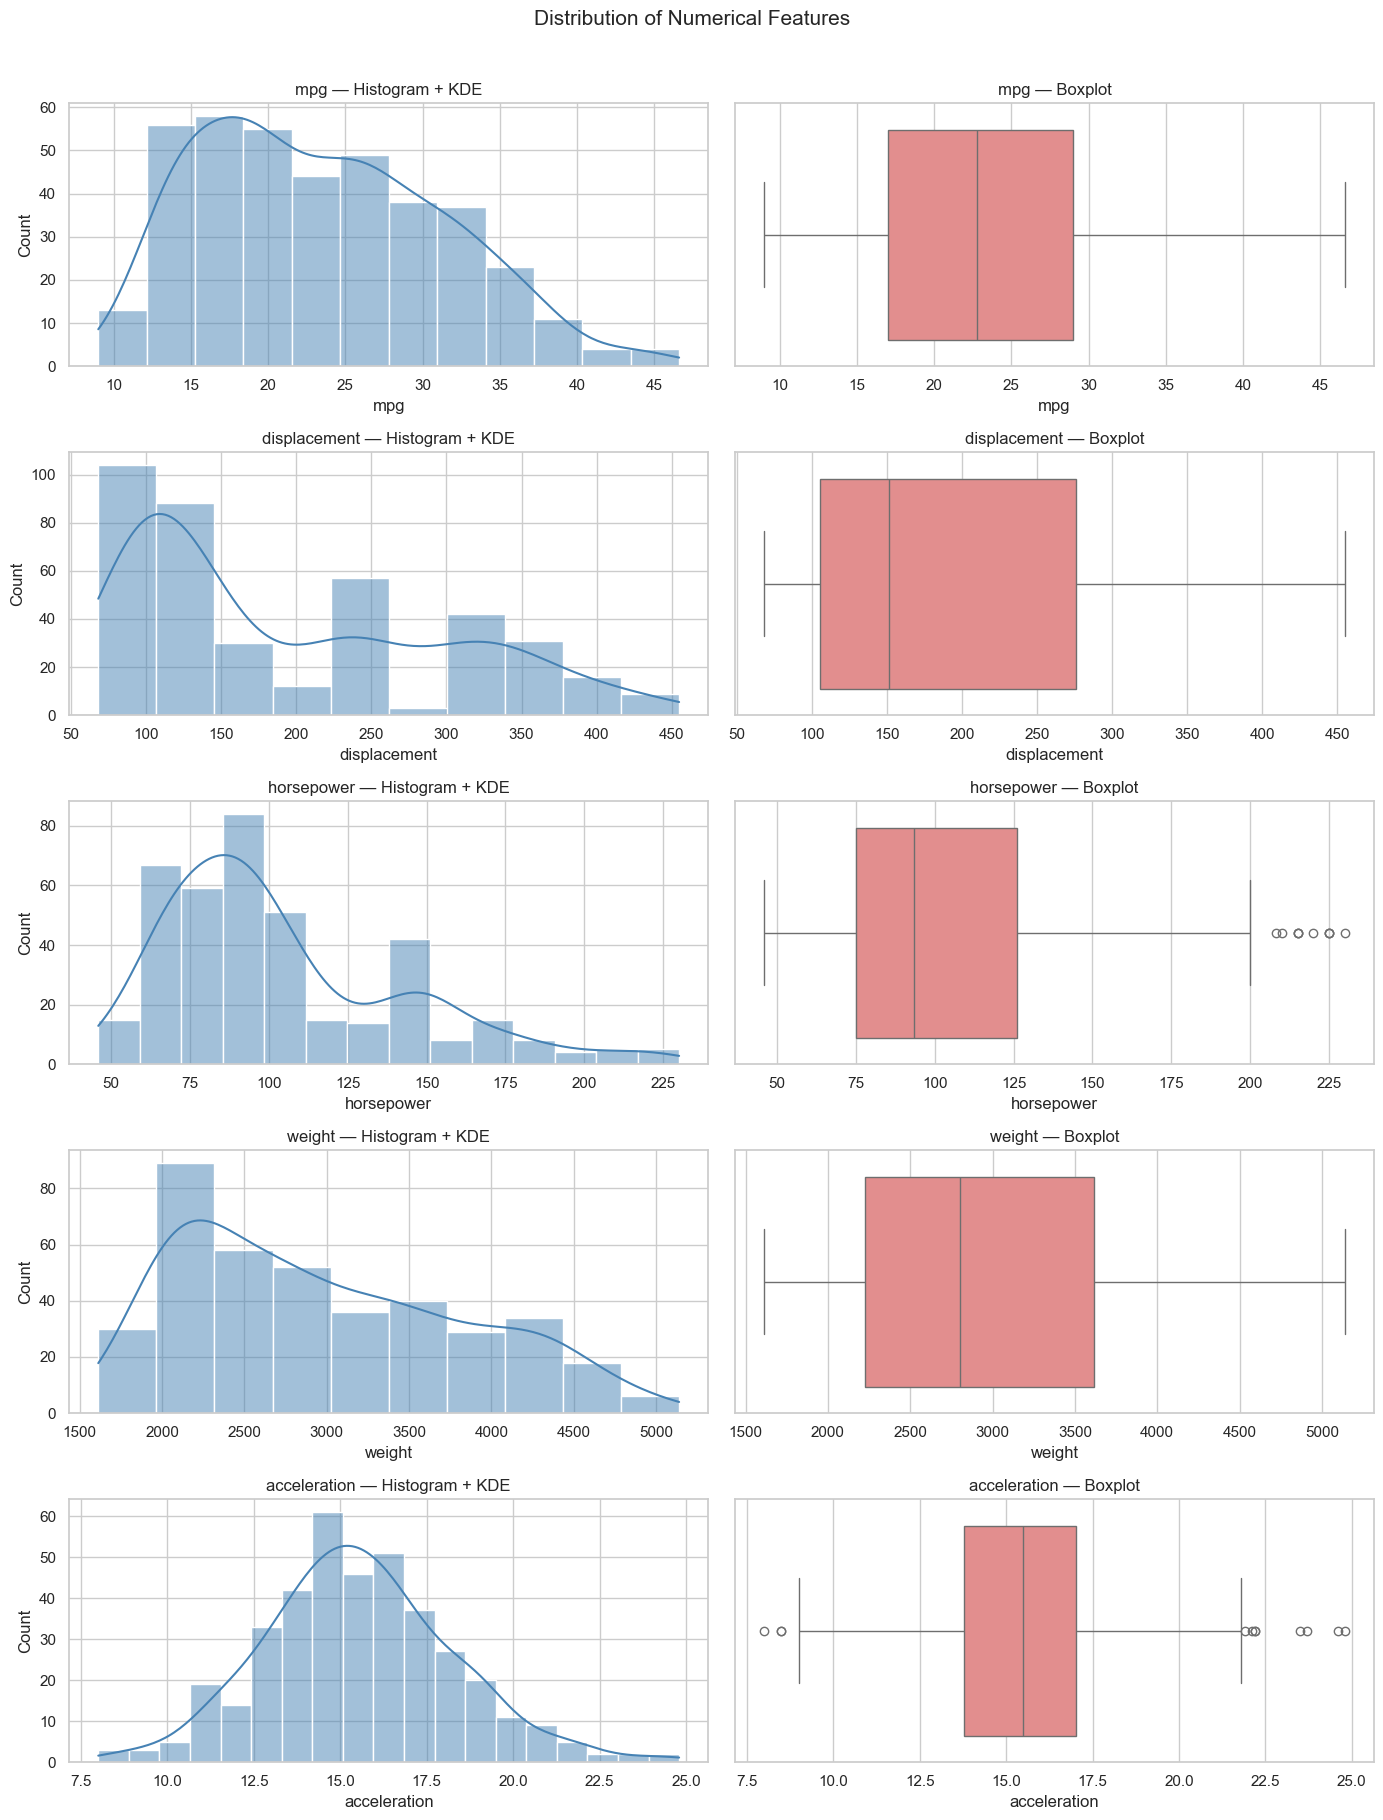

In [14]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 18))

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'{col} — Histogram + KDE')
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i][1], color='lightcoral')
    axes[i][1].set_title(f'{col} — Boxplot')

plt.suptitle('Distribution of Numerical Features', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()


In [15]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
    # TODO: implement
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)
    return series[mask]

print("=== Outlier counts (Tukey/IQR method) ===")
for col in num_cols:
    n = len(tukey_outliers(df[col]))
    print(f"  {col:15s}: {n} outliers")




=== Outlier counts (Tukey/IQR method) ===
  mpg            : 0 outliers
  displacement   : 0 outliers
  horsepower     : 10 outliers
  weight         : 0 outliers
  acceleration   : 11 outliers


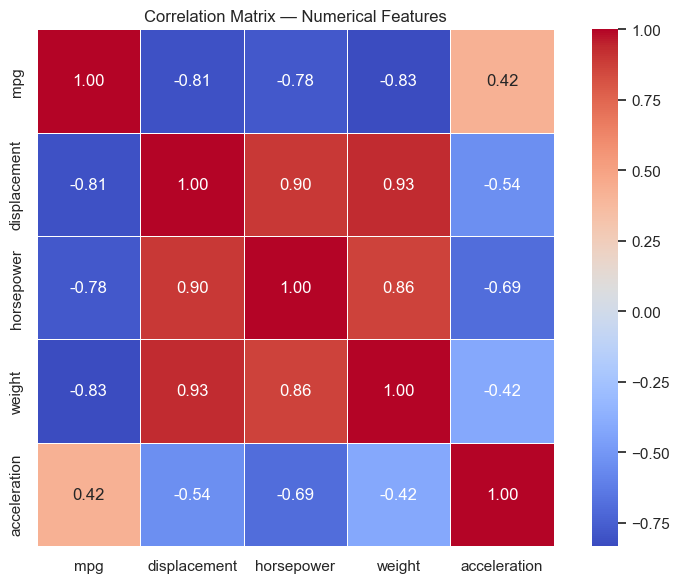


Key correlations with mpg:
weight         -0.832244
displacement   -0.805127
horsepower     -0.778427
acceleration    0.423329
mpg             1.000000
Name: mpg, dtype: float64


In [16]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)

plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout(); plt.show()

print("\nKey correlations with mpg:")
print(corr['mpg'].sort_values())

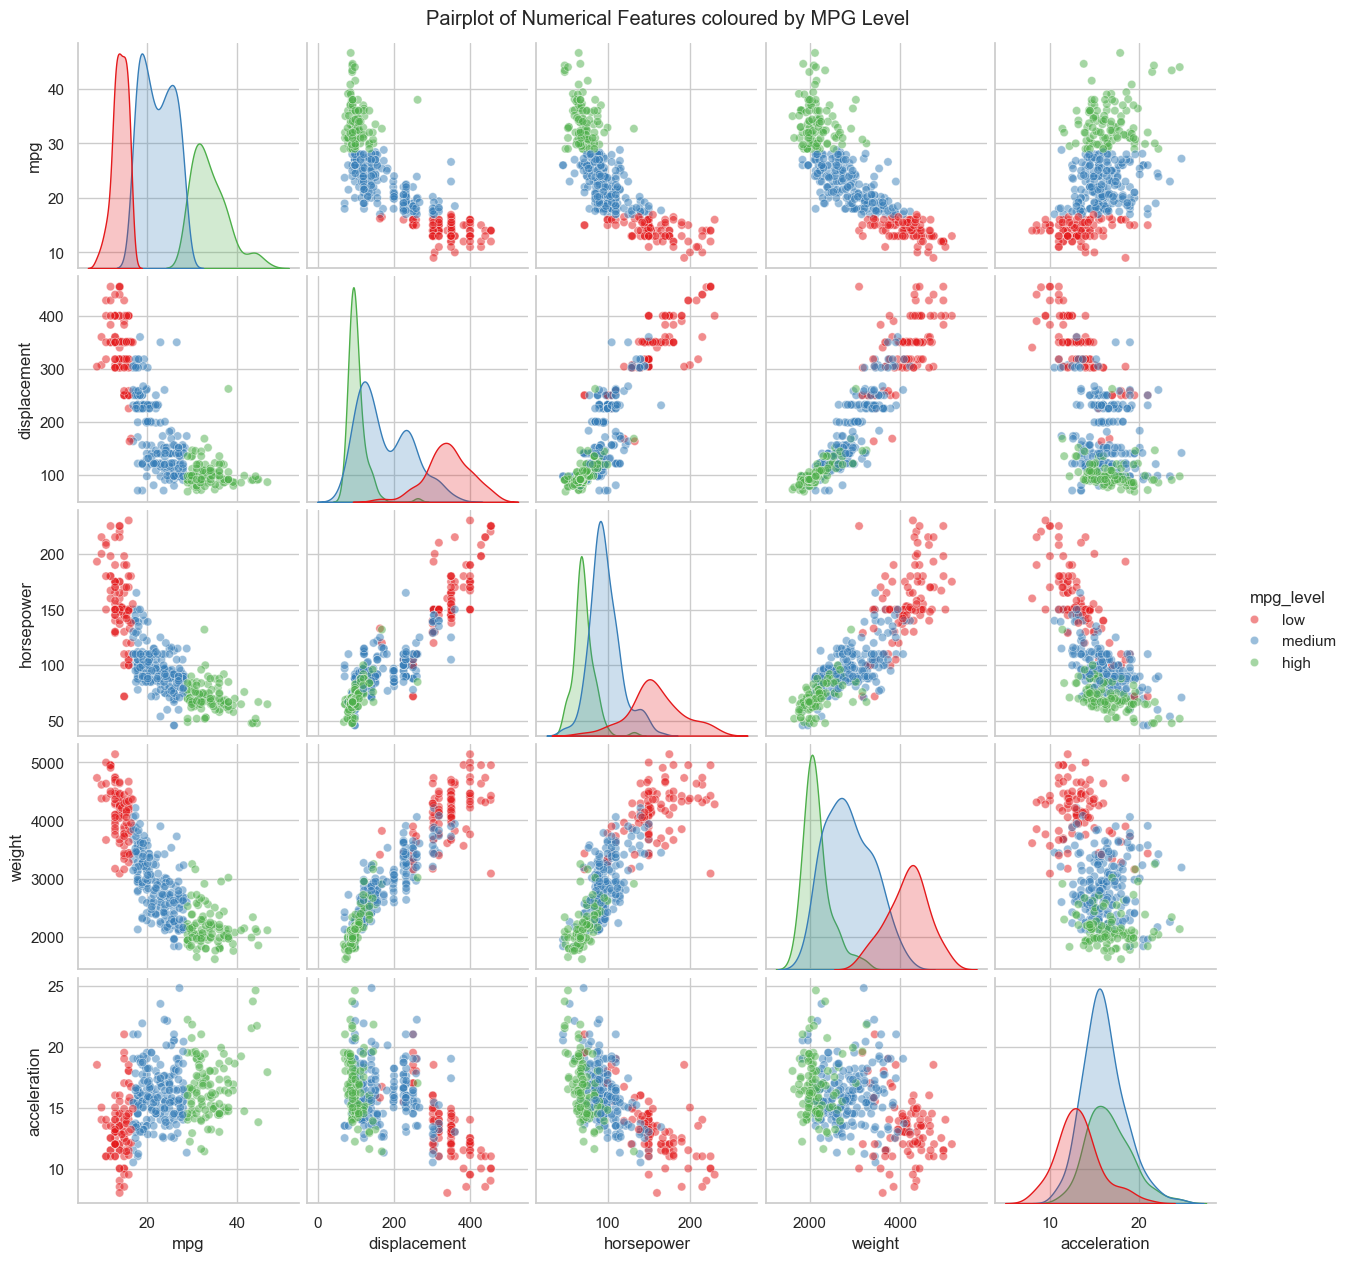

In [17]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level',
             hue_order=['low','medium','high'],
             plot_kws={'alpha':0.5}, palette='Set1')
plt.suptitle('Pairplot of Numerical Features coloured by MPG Level', y=1.01)
plt.show()


**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** ______weight and horsepower_________

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** ______Yes. The acceleration distribution appears roughly bell-shaped and symmetric,
which indicates an approximately Gaussian distribution._________


## Task 7 — Numerical vs Categorical

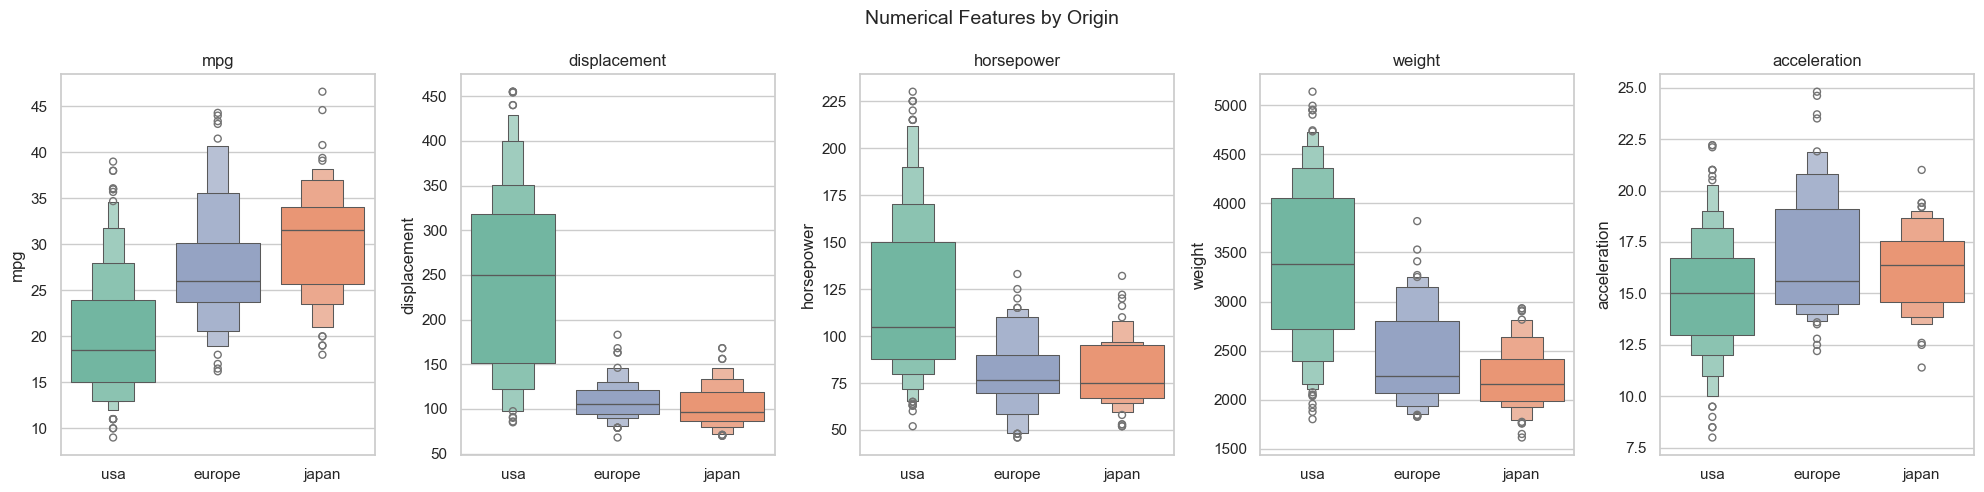

In [19]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    sns.boxenplot(
        data=df,
        x='origin',
        y=col,
        hue='origin',   
        order=['usa', 'europe', 'japan'],
        palette='Set2',
        ax=ax,
        legend=False
    )
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Numerical Features by Origin', fontsize=14)
plt.tight_layout()
plt.show()

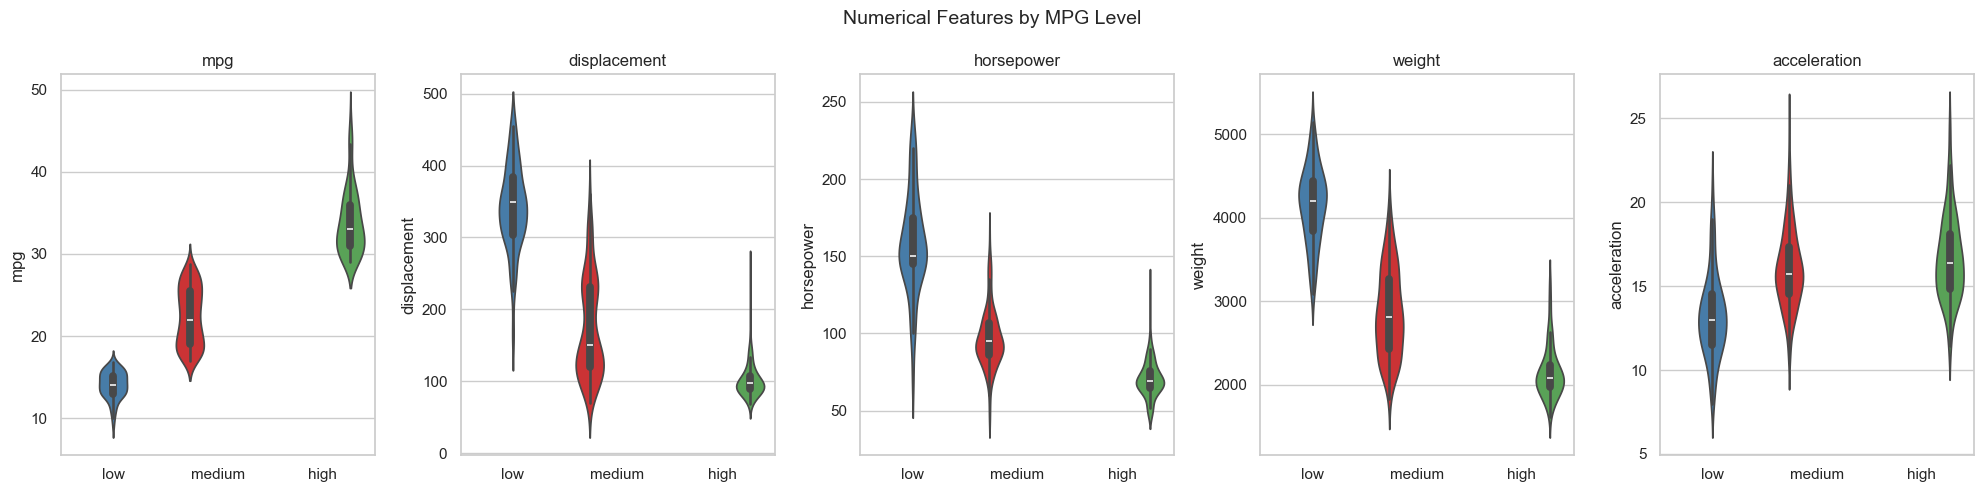

In [21]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    sns.violinplot(
        data=df,
        x='mpg_level',
        y=col,
        hue='mpg_level',   # ✅ FIX
        order=['low','medium','high'],
        palette='Set1',
        ax=ax,
        legend=False       # ✅ avoid duplicate legend
    )
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Numerical Features by MPG Level', fontsize=14)
plt.tight_layout()
plt.show()

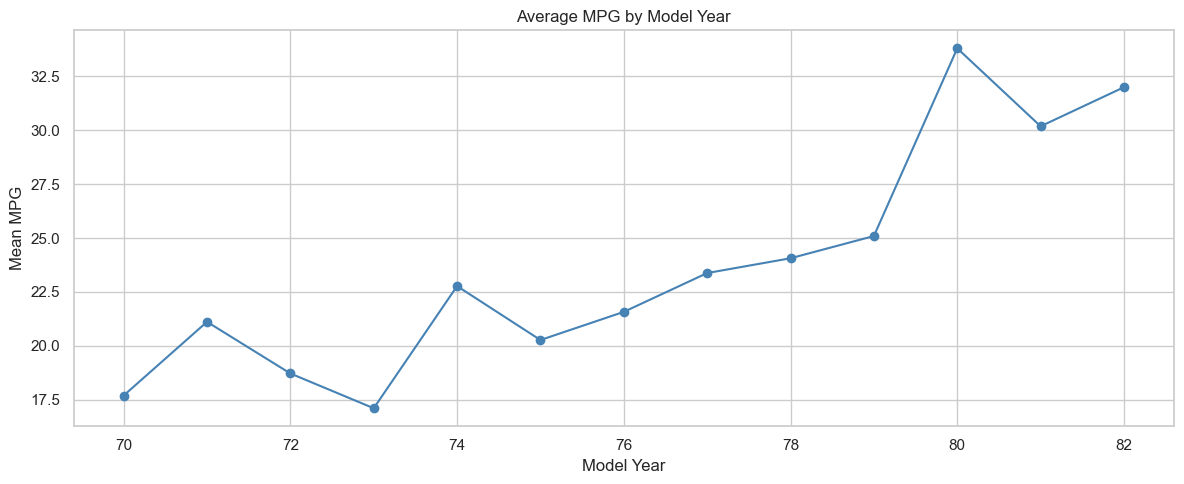

In [22]:
# TODO: Plot a line chart showing mean mpg per model_year

plt.figure(figsize=(12,5))
mpg_year = df.groupby('model_year')['mpg'].mean()
mpg_year.plot(marker='o', color='steelblue')
plt.title('Average MPG by Model Year')
plt.xlabel('Model Year'); plt.ylabel('Mean MPG')
plt.tight_layout(); plt.show()

In [23]:
df.groupby('origin')['mpg'].mean()

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64

**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** ______USA_________

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** ___MPG shows an overall increasing trend as model_year increases, with minor fluctuations.____________


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | Negative | Strong |
| horsepower | Negative | Strong |
| weight | Negative | Strong |
| acceleration | Slight positive | Weak |
| cylinders | Negative | Strong |
| origin | Japan high, USA low | Medium |
| model_year | Positive | Strong |
